In [1]:
import pandas as pd
# โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/Email1_QC_Results_Batch.xlsx'
df_final = pd.read_excel(file_path)

User10 Dusty Purple #A381B2

👤 Analysis for: U162b9506fbf2913990161a40f01f54da
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 1927 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 2.44
🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม (Upper Limit): 3.99


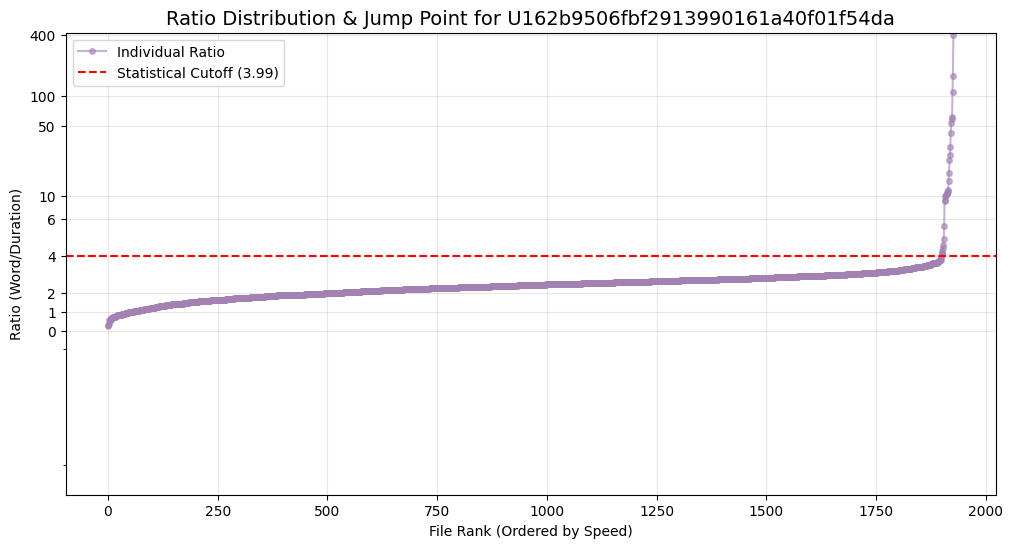

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. ดึงข้อมูลเฉพาะ User สีม่วง
speaker_col = df_final.columns[10]
target_user = 'U162b9506fbf2913990161a40f01f54da'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# 3. คำนวณจุดตัดทางสถิติ (IQR Method)
Q1 = user_data['ratio'].quantile(0.25)
Q3 = user_data['ratio'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)  # เกณฑ์มาตรฐานที่เริ่มมองว่าเป็น Outlier

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม (Upper Limit): {upper_limit:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#A381B2', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Statistical Cutoff ({upper_limit:.2f})')
plt.title(f'Ratio Distribution & Jump Point for U162b9506fbf2913990161a40f01f54da', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')
plt.yscale('symlog', linthresh=6) # linthresh=10 คือให้ช่วง 0-10 แสดงผลแบบปกติ (Linear)
# ปรับเลขแกน Y ให้ดูง่ายขึ้น (ใส่เลขที่เราอยากเห็น)
plt.yticks([0, 1, 2, 3.99, 6, 10, 50, 100, 400])
plt.gca().get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import IPython.display as ipd
import os
import requests

# ตั้งค่าโฟลเดอร์สำหรับ Audit ชั่วคราว
audit_temp_dir = 'audit_temp_samples'
if not os.path.exists(audit_temp_dir):
    os.makedirs(audit_temp_dir)

# กรองไฟล์ที่ Ratio >= จุดตัด
samples_to_audit = user_data[user_data['ratio'] >= upper_limit]

print(f"🎧 กำลังโหลดไฟล์เพื่อตรวจสอบ (Ratio >= {upper_limit:.2f})")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audio'] 
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}.wav")
    
    # ดาวน์โหลดไฟล์ (ถ้ายังไม่มีในโฟลเดอร์ audit_temp)
    if not os.path.exists(local_filename):
        try:
            r = requests.get(audio_url, allow_redirects=True)
            with open(local_filename, 'wb') as f:
                f.write(r.content)
        except Exception as e:
            print(f"❌ โหลดไฟล์ Index {index} ไม่สำเร็จ: {e}")
            continue

    # 4. แสดงผลเพื่อฟัง
    print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
    print(f"📝 Text: {row['text']}")
    display(ipd.Audio(local_filename))
    print("-" * 30)

🎧 กำลังโหลดไฟล์เพื่อตรวจสอบ (Ratio >= 1.67)
--------------------------------------------------
🔍 [Index: 561] | Ratio: 1.68
📝 Text: ข้างหลังคือ บีเอเอซี ดอท โออาร์ ดอท ทีเอช ครับ


------------------------------
🔍 [Index: 477] | Ratio: 1.68
📝 Text: โอ แอล ไอ วี อี แอท สตูเดนต์ ดอท เอซี ดอท ยูเค


------------------------------


User1 Light Teal #8CBBB1

👤 Analysis for: U7ec232d5640ea79fe686775435f09ee5
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 702 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 2.18
🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P99.5: 4.04


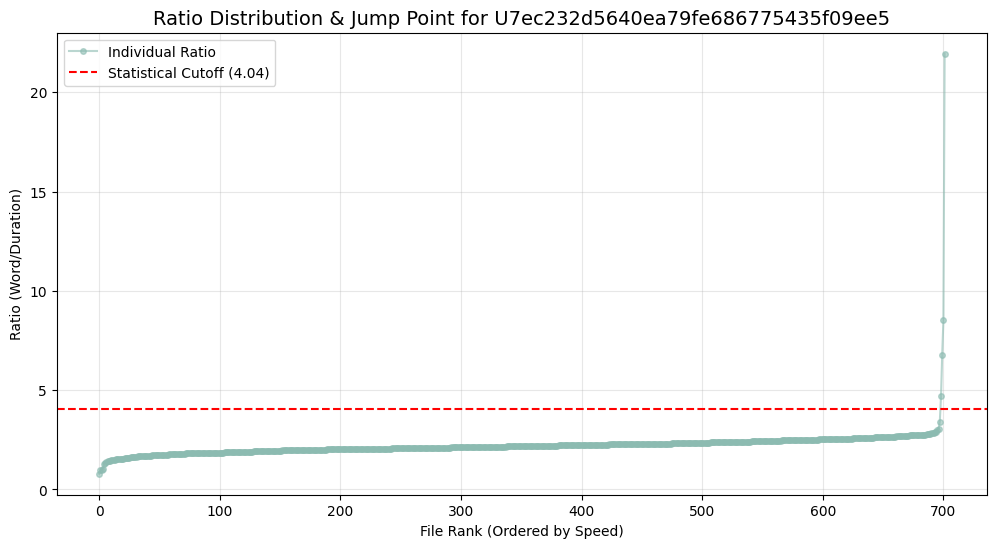

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Light Teal
speaker_col = df_final.columns[10]
target_user = 'U7ec232d5640ea79fe686775435f09ee5'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 0.995
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#8CBBB1', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for U7ec232d5640ea79fe686775435f09ee5', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')


plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import IPython.display as ipd
import os
import requests

# ตั้งค่าโฟลเดอร์สำหรับ Audit ชั่วคราว
audit_temp_dir = 'audit_temp_samples'
if not os.path.exists(audit_temp_dir):
    os.makedirs(audit_temp_dir)

# กรองไฟล์ที่ Ratio >= จุดตัด
samples_to_audit = user_data[user_data['ratio'] >= custom_cutoff]

print(f"🎧 กำลังโหลดไฟล์เพื่อตรวจสอบ (Ratio >= {custom_cutoff:.2f})")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audio'] 
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}.wav")
    
    # ดาวน์โหลดไฟล์ (ถ้ายังไม่มีในโฟลเดอร์ audit_temp)
    if not os.path.exists(local_filename):
        try:
            r = requests.get(audio_url, allow_redirects=True)
            with open(local_filename, 'wb') as f:
                f.write(r.content)
        except Exception as e:
            print(f"❌ โหลดไฟล์ Index {index} ไม่สำเร็จ: {e}")
            continue

    # 4. แสดงผลเพื่อฟัง
    print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
    print(f"📝 Text: {row['text']}")
    display(ipd.Audio(local_filename))
    print("-" * 30)

User2 Pale Yellow #F2F1B0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Pale Yellow
speaker_col = df_final.columns[10]
target_user = 'Ue8be90f19798644e8dcd5cb41658d814'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# 3. คำนวณจุดตัดทางสถิติ (IQR Method)
Q1 = user_data['ratio'].quantile(0.25)
Q3 = user_data['ratio'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)  # เกณฑ์มาตรฐานที่เริ่มมองว่าเป็น Outlier

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม (Upper Limit): {upper_limit:.2f}")



# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#F2F1B0', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Statistical Cutoff ({upper_limit:.2f})')
plt.title(f'Ratio Distribution & Jump Point for Ue8be90f19798644e8dcd5cb41658d814', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User3 Periwinkle #B1B6D1

👤 Analysis for: U4a2e7b8aeca91ff028d513a6ce2f17c6
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 1935 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 2.40
🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P99.8: 3.56


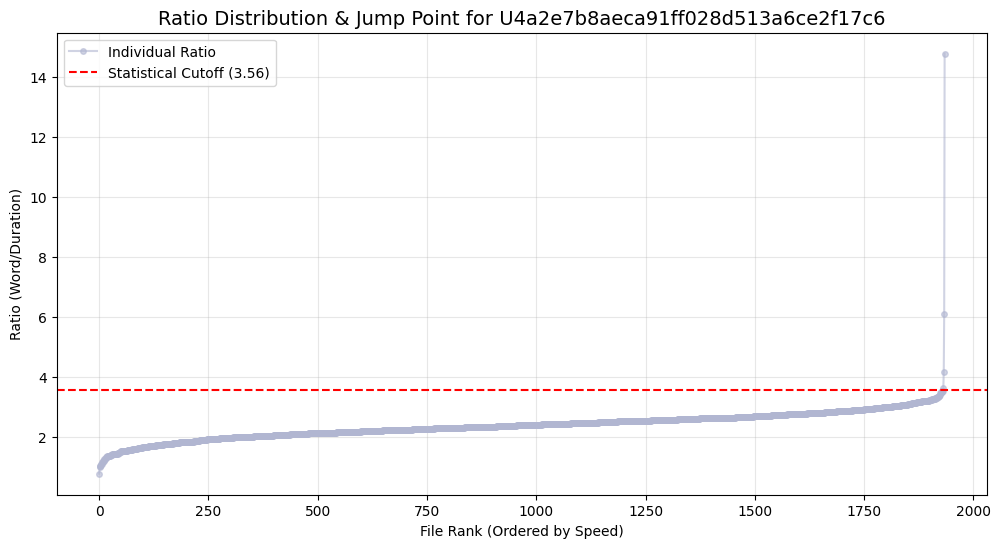

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Periwinkle
speaker_col = df_final.columns[10]
target_user = 'U4a2e7b8aeca91ff028d513a6ce2f17c6'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 0.998
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")


# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#B1B6D1', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for U4a2e7b8aeca91ff028d513a6ce2f17c6', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User4 Muted Coral	#E68A81

👤 Analysis for: Ud40c3d403969cea09ec1ea25c92454b5
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 858 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 2.56
🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P99.2: 4.62


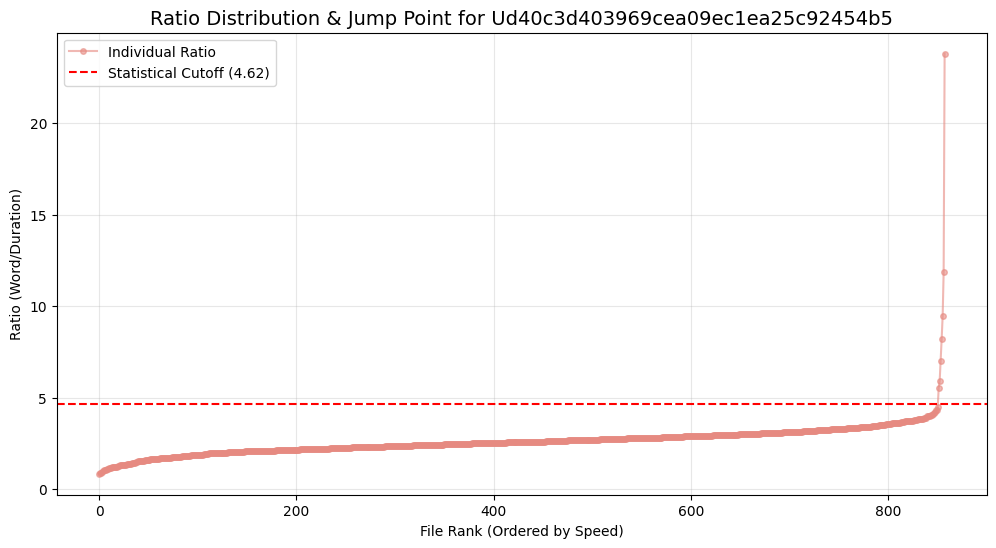

In [142]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Muted Coral
speaker_col = df_final.columns[10]
target_user = 'Ud40c3d403969cea09ec1ea25c92454b5'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 0.992
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")


# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#E68A81', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for Ud40c3d403969cea09ec1ea25c92454b5', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User5 Uf42633936cd02dc2dcb5917e5e3af451
Steel Blue	#7698B3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Steel Blue	
speaker_col = df_final.columns[10]
target_user = 'Uf42633936cd02dc2dcb5917e5e3af451'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 0.994
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")


# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#7698B3', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for Uf42633936cd02dc2dcb5917e5e3af451', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User6 UafTIbaTosdL2Y7nSvbRWdmNsPV2
Light Orange	#F0B884

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Light Orange	
speaker_col = df_final.columns[10]
target_user = 'UafTIbaTosdL2Y7nSvbRWdmNsPV2'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# 3. คำนวณจุดตัดทางสถิติ (IQR Method)
Q1 = user_data['ratio'].quantile(0.25)
Q3 = user_data['ratio'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)  # เกณฑ์มาตรฐานที่เริ่มมองว่าเป็น Outlier

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม (Upper Limit): {upper_limit:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#F0B884', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Statistical Cutoff ({upper_limit:.2f})')
plt.title(f'Ratio Distribution & Jump Point for UafTIbaTosdL2Y7nSvbRWdmNsPV2', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User7 U247513c501d5d9ab63dd1c12b40256b2
Apple Green	#ACD17C

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Apple Green	
speaker_col = df_final.columns[10]
target_user = 'U247513c501d5d9ab63dd1c12b40256b2'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 1
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#ACD17C', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for U247513c501d5d9ab63dd1c12b40256b2', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User8 U60b22de03f791141bfbfef3028b416a4
Pink	#E6BDD1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Pink	
speaker_col = df_final.columns[10]
target_user = 'U60b22de03f791141bfbfef3028b416a4'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 1
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#E6BDD1', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for U60b22de03f791141bfbfef3028b416a4', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User9 U835bf5297c759ddd8cb2d866f023915c
Light Grey	#D4D4D4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Light Grey	
speaker_col = df_final.columns[10]
target_user = 'U835bf5297c759ddd8cb2d866f023915c'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 1
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")


# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#D4D4D4', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for U835bf5297c759ddd8cb2d866f023915c', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User11 Ud84a8838b38131513c5d72336fcadb8b
Pale Green	#C1D6B1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Pale Green	
speaker_col = df_final.columns[10]
target_user = 'Ud84a8838b38131513c5d72336fcadb8b'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# --- ปรับจาก IQR เป็น Percentile ---
# ลองเริ่มที่ 99% (คือเอาเฉพาะตัวที่ Top 1% ของความเร็วคนนี้ออก)
percentile_value = 0.998
custom_cutoff = user_data['ratio'].quantile(percentile_value)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม จุดตัดที่ P{percentile_value*100}: {custom_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#C1D6B1', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(custom_cutoff, color='red', linestyle='--', label=f'Statistical Cutoff ({custom_cutoff:.2f})')
plt.title(f'Ratio Distribution & Jump Point for Ud84a8838b38131513c5d72336fcadb8b', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

User12 u1jzmPGpYpfnIFZ4fOwKYU9LNjB2
Soft Mustard	#E6D681

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลเฉพาะ User Soft Mustard
speaker_col = df_final.columns[10]
target_user = 'u1jzmPGpYpfnIFZ4fOwKYU9LNjB2'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

# 3. คำนวณจุดตัดทางสถิติ (IQR Method)
Q1 = user_data['ratio'].quantile(0.25)
Q3 = user_data['ratio'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)  # เกณฑ์มาตรฐานที่เริ่มมองว่าเป็น Outlier

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดที่ข้อมูลเริ่ม 'โดด' ออกจากกลุ่ม (Upper Limit): {upper_limit:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ของ Ratio
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= '#E6D681', markersize=4, alpha=0.6, label='Individual Ratio')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Statistical Cutoff ({upper_limit:.2f})')
plt.title(f'Ratio Distribution & Jump Point for u1jzmPGpYpfnIFZ4fOwKYU9LNjB2', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

plt.xlabel('File Rank (Ordered by Speed)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import IPython.display as ipd
import os
import requests

# ตั้งค่าโฟลเดอร์สำหรับ Audit ชั่วคราว
audit_temp_dir = 'audit_temp_samples'
if not os.path.exists(audit_temp_dir):
    os.makedirs(audit_temp_dir)
    
# กรองไฟล์ที่ Ratio >= จุดตัด
samples_to_audit = user_data[user_data['ratio'] >= custom_cutoff]

print(f"🎧 กำลังโหลดไฟล์เพื่อตรวจสอบ (Ratio >= {custom_cutoff:.2f})")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audio'] 
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}.wav")
    
    # ดาวน์โหลดไฟล์ (ถ้ายังไม่มีในโฟลเดอร์ audit_temp)
    if not os.path.exists(local_filename):
        try:
            r = requests.get(audio_url, allow_redirects=True)
            with open(local_filename, 'wb') as f:
                f.write(r.content)
        except Exception as e:
            print(f"❌ โหลดไฟล์ Index {index} ไม่สำเร็จ: {e}")
            continue

    # 4. แสดงผลเพื่อฟัง
    print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
    print(f"📝 Text: {row['text']}")
    display(ipd.Audio(local_filename))
    print("-" * 30)

In [133]:
import shutil

# ลบโฟลเดอร์ที่เก็บไฟล์ Audit ทิ้งทั้งหมด
if os.path.exists(audit_temp_dir):
    shutil.rmtree(audit_temp_dir)
    print(f"🗑️ ลบไฟล์ใน '{audit_temp_dir}' เรียบร้อยแล้ว")
else:
    print("✨ ไม่มีไฟล์ค้างอยู่แล้ว")

🗑️ ลบไฟล์ใน 'audit_temp_samples' เรียบร้อยแล้ว
